In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math
import tifffile

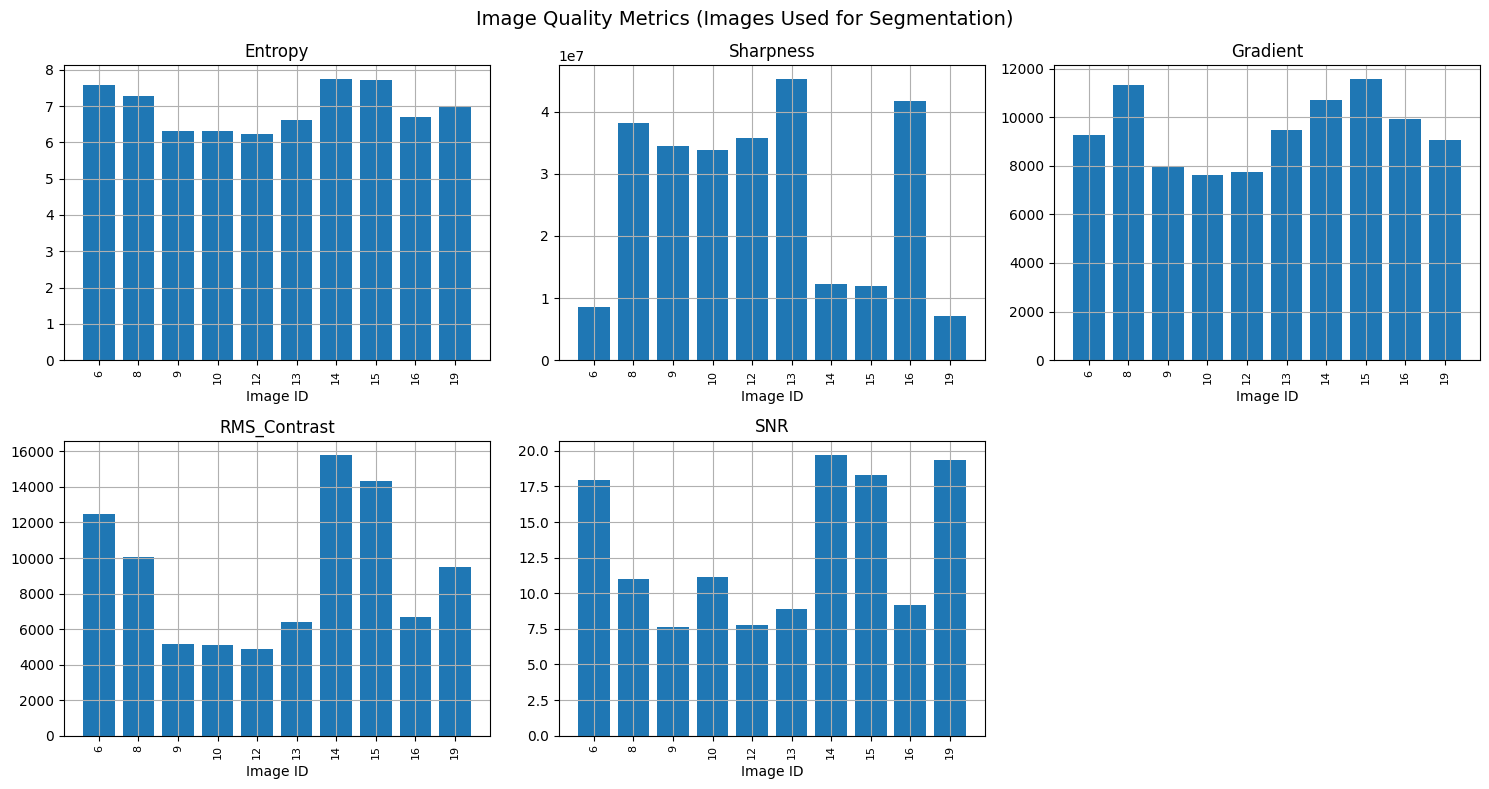

In [ ]:
BASE_DIR = Path.cwd().parents[1]


# Load image quality results
QUALITY_FILE = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "results"
    / "image_quality_results.csv"
)

quality_results = pd.read_csv(
    QUALITY_FILE
)


# Load segmentation results
SEG_FILE = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "results"
    / "segmentation_quality.csv"
)

seg_results = pd.read_csv(
    SEG_FILE
)


# Keep only images that have segmentation results
quality_results = quality_results.merge(
    seg_results[
        [
            "detector",
            "sample_state",
            "material",
            "image_id"
        ]
    ],
    on=[
        "detector",
        "sample_state",
        "material",
        "image_id"
    ],
    how="inner"
)


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create grid
cols = 3
rows = math.ceil(len(metrics) / cols)


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, 8)
)


axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    ax.bar(
        quality_results["image_id"].astype(str),
        quality_results[metric]
    )

    ax.set_title(metric)

    ax.set_xlabel("Image ID")

    ax.tick_params(
        axis="x",
        rotation=90,
        labelsize=8
    )

    ax.grid(True)


# Remove unused axes
for ax in axes[len(metrics):]:
    ax.axis("off")


fig.suptitle(
    "Image Quality Metrics (Images Used for Segmentation)",
    fontsize=14
)


plt.tight_layout()
plt.show()

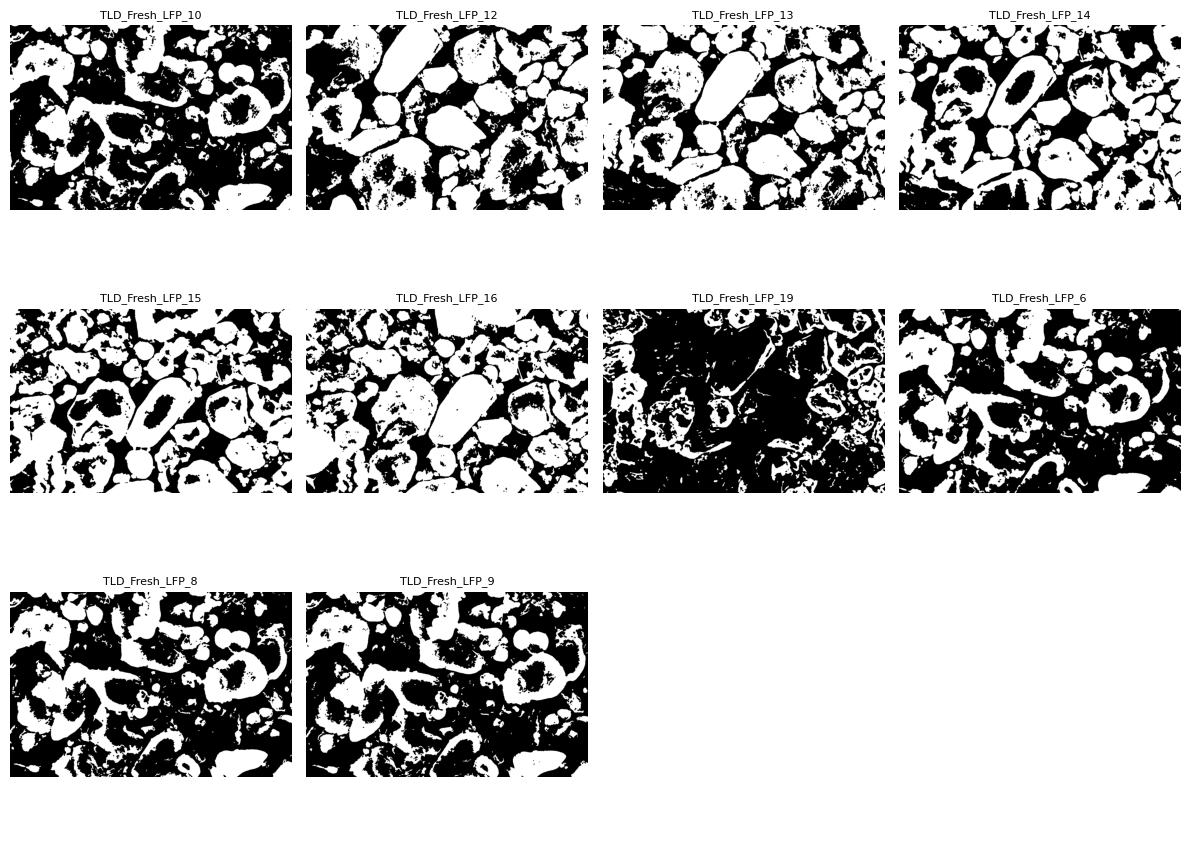

In [ ]:
BASE_DIR = Path.cwd().parents[1]  # Adjust parent index if needed (e.g., parents[2])
MASK_DIR = BASE_DIR / "FIB_SEM_optimization" / "images" / "segmented_masks"


mask_files = sorted(
    MASK_DIR.glob("*_mask.tif")
)


# Number of images
n_images = len(mask_files)

# Grid size
cols = 4
rows = math.ceil(n_images / cols)


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(12, 3 * rows)
)


# Handle case of only one row
axes = axes.flatten()


for ax, mask_path in zip(axes, mask_files):

    mask = tifffile.imread(
        mask_path
    )

    ax.imshow(
        mask,
        cmap="gray"
    )

    ax.set_title(
        mask_path.stem.replace("_mask", ""),
        fontsize=8
    )

    ax.axis("off")


# Remove empty plots
for ax in axes[n_images:]:
    ax.axis("off")


plt.tight_layout()
plt.show()

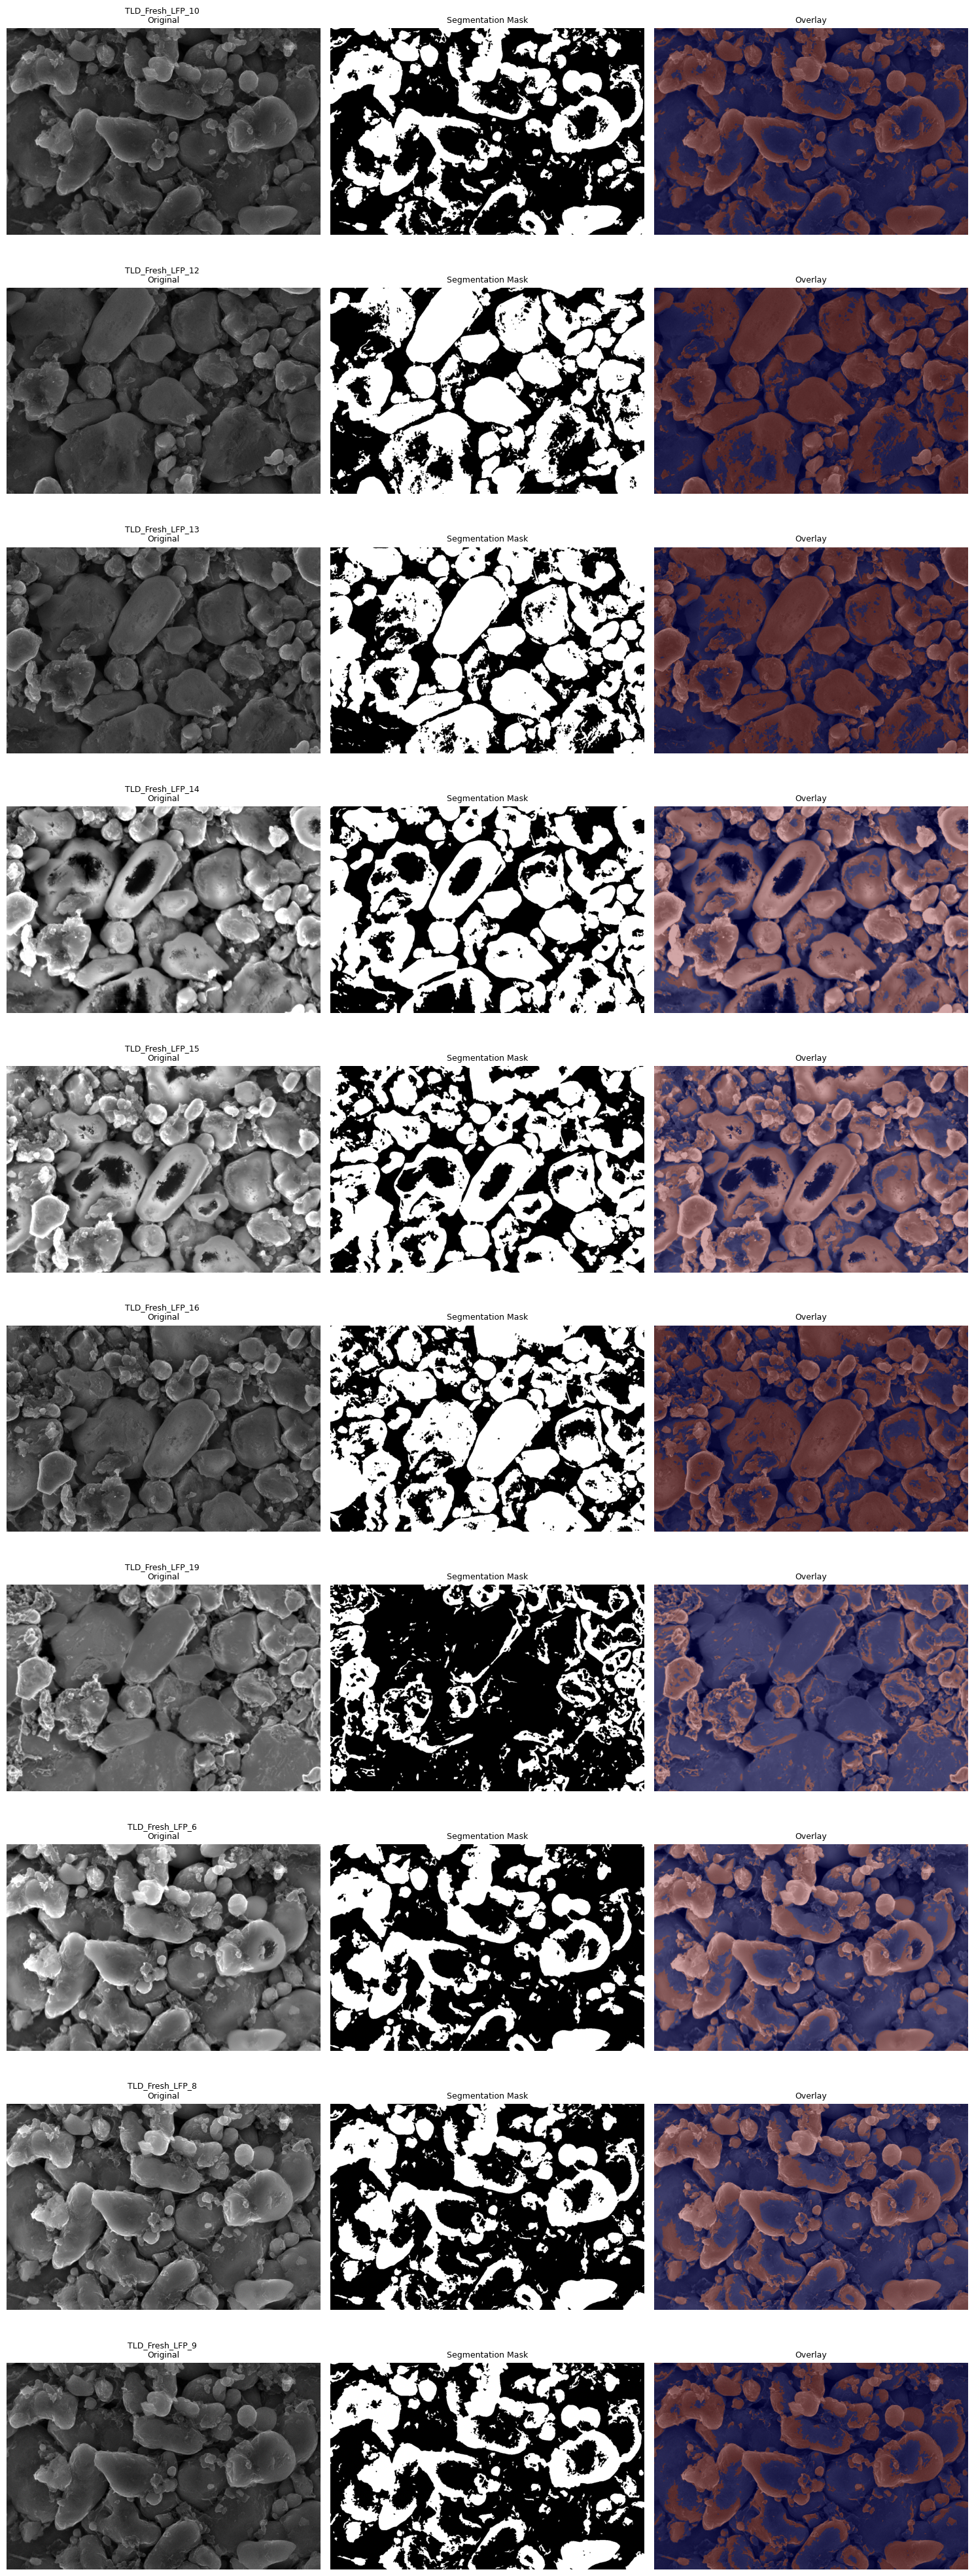

In [ ]:
from pathlib import Path
import tifffile
import matplotlib.pyplot as plt


BASE_DIR = Path.cwd().parents[1]

MASK_DIR = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "images"
    / "segmented_masks"
)

IMAGE_DIR = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "images"
    / "cropped"
    / "Tested_for_segmentation"
)


mask_files = sorted(
    MASK_DIR.glob("*_mask.tif")
)


n_images = len(mask_files)


# Three columns:
# Original | Mask | Overlay
cols = 3
rows = n_images


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, 4 * rows)
)


# Handle single image case
if n_images == 1:
    axes = axes.reshape(1, -1)


for i, mask_path in enumerate(mask_files):

    # Load mask
    mask = tifffile.imread(
        mask_path
    )


    # Find original image
    image_path = (
        IMAGE_DIR
        / mask_path.name.replace(
            "_mask",
            ""
        )
    )


    image = tifffile.imread(
        image_path
    )


    # -----------------------
    # Original image
    # -----------------------
    axes[i, 0].imshow(
        image,
        cmap="gray"
    )

    axes[i, 0].set_title(
        f"{mask_path.stem.replace('_mask','')} \nOriginal",
        fontsize=9
    )

    axes[i, 0].axis("off")


    # -----------------------
    # Segmentation mask
    # -----------------------
    axes[i, 1].imshow(
        mask,
        cmap="gray"
    )

    axes[i, 1].set_title(
        "Segmentation Mask",
        fontsize=9
    )

    axes[i, 1].axis("off")


    # -----------------------
    # Overlay
    # -----------------------
    axes[i, 2].imshow(
        image,
        cmap="gray"
    )

    axes[i, 2].imshow(
        mask,
        cmap="jet",
        alpha=0.35
    )

    axes[i, 2].set_title(
        "Overlay",
        fontsize=9
    )

    axes[i, 2].axis("off")


plt.tight_layout()
plt.show()

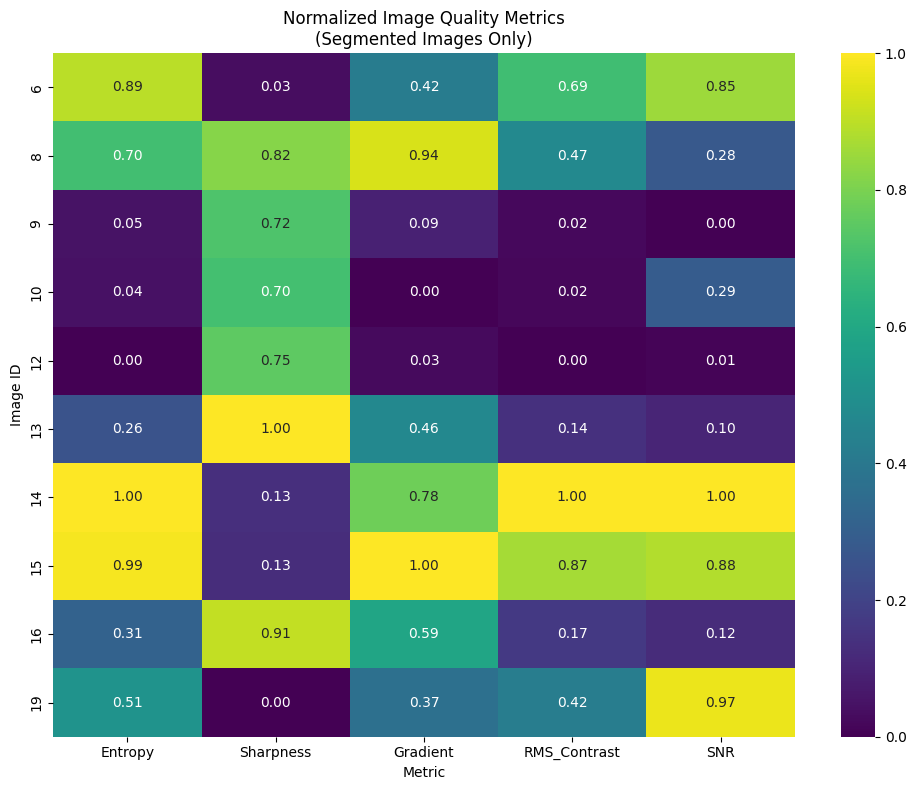

In [ ]:
# Load segmentation results
SEG_FILE = BASE_DIR / "FIB_SEM_optimization" / "results" / "segmentation_quality.csv"

seg_results = pd.read_csv(
    SEG_FILE
)


# Keep only segmented images
quality_results_filtered = quality_results.merge(
    seg_results[["image_id"]],
    on="image_id",
    how="inner"
)


# Create normalized metric table
quality_norm = quality_results_filtered.set_index(
    "image_id"
)[metrics]


# Normalize each metric between 0 and 1
quality_norm = (
    quality_norm - quality_norm.min()
) / (
    quality_norm.max() - quality_norm.min()
)


plt.figure(figsize=(10, 8))

sns.heatmap(
    quality_norm,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)


plt.title(
    "Normalized Image Quality Metrics\n(Segmented Images Only)"
)

plt.xlabel("Metric")
plt.ylabel("Image ID")


plt.tight_layout()
plt.show()

In [71]:
from sklearn.preprocessing import MinMaxScaler


score_metrics = [
    "separability",
    "segmented_fraction",
    "connected_components",
    "mean_region_area"
]


scaler = MinMaxScaler()


seg_results[
    score_metrics
] = scaler.fit_transform(
    seg_results[score_metrics]
)


seg_results["segmentation_score"] = (
    0.4 * seg_results["separability"]
    +
    0.2 * seg_results["connected_components"]
    +
    0.2 * seg_results["mean_region_area"]
    -
    0.2 * seg_results["threshold_instability"]
)


seg_results.sort_values(
    "segmentation_score",
    ascending=False
)

,threshold,segmented_fraction,connected_components,mean_region_area,median_region_area,separability,threshold_instability,detector,sample_state,material,image_id,segmentation_score
4,0.474615,0.961462,0.108108,0.766622,138.0,1.000000,0.098771,TLD,Fresh,LFP,15,0.555192
3,0.447266,0.940575,0.000000,1.000000,117.0,0.924719,0.089429,TLD,Fresh,LFP,14,0.552002
7,0.455078,0.372951,0.529730,0.180278,127.0,0.601137,0.118865,TLD,Fresh,LFP,6,0.358683
9,0.259648,0.347853,0.789189,0.104749,69.0,0.468187,0.123726,TLD,Fresh,LFP,9,0.341317
8,0.381725,0.375585,0.772973,0.114601,92.5,0.466515,0.125347,TLD,Fresh,LFP,8,0.339051
0,0.263647,0.348237,0.718919,0.120157,95.5,0.467377,0.125633,TLD,Fresh,LFP,10,0.329640
5,0.263381,1.000000,0.264865,0.567553,91.0,0.387225,0.128246,TLD,Fresh,LFP,16,0.295724
2,0.238080,0.991000,0.281081,0.546987,63.0,0.155421,0.135890,TLD,Fresh,LFP,13,0.200604
1,0.222973,0.905026,0.324324,0.473156,78.0,0.131355,0.138421,TLD,Fresh,LFP,12,0.184354
6,0.466793,0.000000,1.000000,0.000000,88.0,0.000000,0.183415,TLD,Fresh,LFP,19,0.163317


In [72]:
from sklearn.preprocessing import MinMaxScaler


quality_metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Make a copy to avoid modifying original data
quality_scored = quality_results.copy()


# Normalize metrics 0-1
scaler = MinMaxScaler()

quality_scored[
    quality_metrics
] = scaler.fit_transform(
    quality_scored[quality_metrics]
)


# Calculate image quality score
quality_scored["image_quality_score"] = (
    0.05 * quality_scored["Entropy"]
    +
    0.20 * quality_scored["Sharpness"]
    +
    0.25 * quality_scored["Gradient"]
    +
    0.20 * quality_scored["RMS_Contrast"]
    +
    0.30 * quality_scored["SNR"]
)


# Rank images
quality_scored = quality_scored.sort_values(
    "image_quality_score",
    ascending=False
)


quality_scored[
    [
        "image_id",
        "image_quality_score",
        "SNR",
        "Gradient",
        "Sharpness",
        "RMS_Contrast",
        "Entropy"
    ]
]

,image_id,image_quality_score,SNR,Gradient,Sharpness,RMS_Contrast,Entropy
6,14,0.772032,1.000000,0.781006,0.133903,1.000000,1.000000
7,15,0.763450,0.884667,1.000000,0.127388,0.866043,0.987281
1,8,0.611063,0.276970,0.941295,0.817017,0.471548,0.698697
0,6,0.551118,0.854773,0.416058,0.034734,0.694897,0.894904
9,19,0.492491,0.971575,0.365028,0.000000,0.420531,0.513098
8,16,0.414140,0.124497,0.586173,0.908113,0.165775,0.309406
5,13,0.388147,0.103934,0.464896,1.000000,0.139935,0.255116
3,10,0.232415,0.287927,0.000000,0.700140,0.019289,0.043020
2,9,0.173943,0.000000,0.092661,0.718877,0.022625,0.049554
4,12,0.159583,0.008345,0.026209,0.752634,0.000000,0.000000


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# -------------------------------
# Load results
# -------------------------------

quality_results = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "image_quality_results.csv"
)
quality_results_normalised = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "image_quality_results_normalised.csv"
)

seg_results = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "segmentation_quality.csv"
)


# -------------------------------
# Image Quality Score
# -------------------------------

quality_metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


quality_scored_1 = quality_results.copy()

scaler = MinMaxScaler()

quality_scored_1[
    quality_metrics
] = scaler.fit_transform(
    quality_scored_1[quality_metrics]
)


quality_scored_1["image_quality_score"] = (
    0.05 * quality_scored_1["Entropy"]
    +
    0.20 * quality_scored_1["Sharpness"]
    +
    0.25 * quality_scored_1["Gradient"]
    +
    0.20 * quality_scored_1["RMS_Contrast"]
    +
    0.30 * quality_scored_1["SNR"]
)


# -------------------------------
# Segmentation Score
# -------------------------------

seg_metrics = [
    "separability",
    "connected_components",
    "mean_region_area"
]


seg_scored = seg_results.copy()


seg_scored[
    seg_metrics
] = scaler.fit_transform(
    seg_scored[seg_metrics]
)


seg_scored["segmentation_score"] = (
    0.40 * seg_scored["separability"]
    +
    0.20 * seg_scored["connected_components"]
    +
    0.20 * seg_scored["mean_region_area"]
    -
    0.20 * seg_scored["threshold_instability"]
)


# -------------------------------
# Combine Scores
# -------------------------------

combined_results = quality_scored.merge(
    seg_scored[
        [
            "detector",
            "sample_state",
            "material",
            "image_id",
            "segmentation_score"
        ]
    ],
    on=[
        "detector",
        "sample_state",
        "material",
        "image_id"
    ],
    how="inner"
)


# Final FIB-SEM optimisation score
combined_results["final_score"] = (
    0.4 * combined_results["image_quality_score"]
    +
    0.6 * combined_results["segmentation_score"]
)


# Rank best images
combined_results = combined_results.sort_values(
    "final_score",
    ascending=False
)


# Display ranking
combined_results[
    [
        "detector",
        "sample_state",
        "material",
        "image_id",
        "image_quality_score",
        "segmentation_score",
        "final_score"
    ]
]

,detector,sample_state,material,image_id,image_quality_score,segmentation_score,final_score
0,TLD,Fresh,LFP,14,0.772032,0.552002,0.640014
1,TLD,Fresh,LFP,15,0.763450,0.555192,0.638495
2,TLD,Fresh,LFP,8,0.611063,0.339051,0.447856
3,TLD,Fresh,LFP,6,0.551118,0.358683,0.435657
5,TLD,Fresh,LFP,16,0.414140,0.295724,0.343091
4,TLD,Fresh,LFP,19,0.492491,0.163317,0.294986
7,TLD,Fresh,LFP,10,0.232415,0.329640,0.290750
6,TLD,Fresh,LFP,13,0.388147,0.200604,0.275621
8,TLD,Fresh,LFP,9,0.173943,0.341317,0.274368
9,TLD,Fresh,LFP,12,0.159583,0.184354,0.174445
